In [3]:
import sys
sys.path.append("..")

from src.data import load_data

df_model, df_enrolled = load_data("../data/data.csv")
print(df_model.shape, df_enrolled.shape)

(3630, 38) (794, 37)


In [4]:
second_sem_cols = [col for col in df_model.columns if col.startswith("curricular_units_2nd_sem")]

X = df_model.drop(columns=second_sem_cols + ["target", "dropout"])
y = df_model["dropout"]

print(second_sem_cols)
print(X.shape)

['curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations']
(3630, 30)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(X_train.shape, X_test.shape)
print(y_train.mean().round(3), y_test.mean().round(3))

(2904, 30) (726, 30)
0.392 0.391


In [9]:
X_train.nunique().sort_values()

daytime_evening_attendance                        2
displaced                                         2
debtor                                            2
educational_special_needs                         2
international                                     2
scholarship_holder                                2
gender                                            2
tuition_fees_up_to_date                           2
application_order                                 6
marital_status                                    6
inflation_rate                                    9
unemployment_rate                                10
gdp                                              10
curricular_units_1st_sem_without_evaluations     11
previous_qualification                           16
course                                           17
application_mode                                 17
nationality                                      18
curricular_units_1st_sem_credited                21
curricular_u

In [11]:
categorical_cols = [
    "marital_status", 
    "nationality", 
    "application_mode", 
    "course", 
    "previous_qualification", 
    "mother_s_qualification", 
    "father_s_qualification", 
    "mother_s_occupation",
    "father_s_occupation"
    ]


binary_cols = [
    "gender", 
    "international", 
    "displaced", 
    "educational_special_needs", 
    "daytime_evening_attendance", 
    "debtor", 
    "tuition_fees_up_to_date", 
    "scholarship_holder"
    ]


numerical_cols = [
    "age_at_enrollment", 
    "application_order", 
    "previous_qualification_grade", 
    "admission_grade", 
    "curricular_units_1st_sem_credited", 
    "curricular_units_1st_sem_enrolled", 
    "curricular_units_1st_sem_evaluations",
    "curricular_units_1st_sem_approved", 
    "curricular_units_1st_sem_grade", 
    "curricular_units_1st_sem_without_evaluations", 
    "unemployment_rate", 
    "inflation_rate", 
    "gdp"
    ]


assert len(categorical_cols) + len(binary_cols) + len(numerical_cols) == X.shape[1]
assert set(categorical_cols + binary_cols + numerical_cols) == set(X.columns)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols),
        ("bin", "passthrough", binary_cols),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [13]:
print(X_train_processed.shape, X_test_processed.shape)

(2904, 221) (726, 221)


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Graduate", "Dropout"]))

              precision    recall  f1-score   support

    Graduate       0.92      0.91      0.92       442
     Dropout       0.87      0.88      0.87       284

    accuracy                           0.90       726
   macro avg       0.89      0.90      0.89       726
weighted avg       0.90      0.90      0.90       726



## Baseline Model: Logistic Regression

| Model                        | Accuracy | Recall (Dropout) | Precision (Dropout) | F1 (Dropout) |
|------------------------------|----------|------------------|---------------------|--------------|
| Naive (always "Graduate")    | 61%      | 0%               | -                   | -            |
| Logistic Regression          | 90%      | 88%              | 87%                 | 87%          |

**Results:**
- **Recall = 88%:** The model finds 88% of students who actually dropped out
  (about 250 out of 284). About 34 at-risk students are missed.
- **Precision = 87%:** When the model predicts "Dropout", it is correct 87% of the time.
  The other 13% are false alarms (students who would have graduated).

**Insight:** Logistic Regression performs much better than the naive baseline,
especially in recall (88% vs 0%). This is a strong starting point.

**Next steps:**
- Analyze the errors with a confusion matrix.
- Try stronger models (e.g. Random Forest, XGBoost) and compare them to this baseline.
- Check how much `tuition_fees_up_to_date` affects performance, because of possible data leakage.

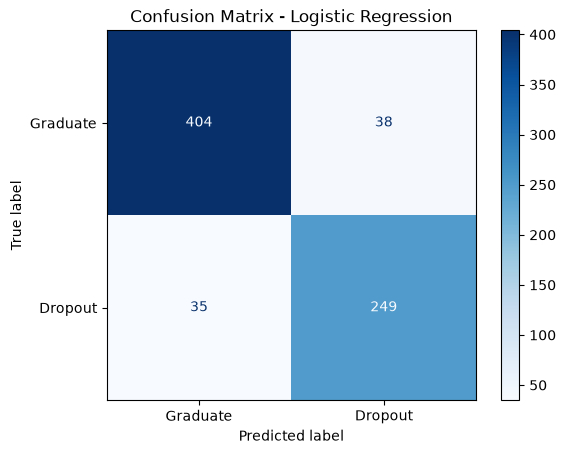

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Graduate", "Dropout"],
    cmap="Blues",
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

- **Recall = 88%:** The model finds 88% of students who actually dropped out
  (249 out of 284). 35 at-risk students are missed.


**Insight:** The model misses 35 dropout students (false negatives). These are the
most costly errors, because these students will not get help.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42)),
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Graduate", "Dropout"]))

              precision    recall  f1-score   support

    Graduate       0.89      0.94      0.92       442
     Dropout       0.90      0.82      0.86       284

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.89       726
weighted avg       0.89      0.89      0.89       726



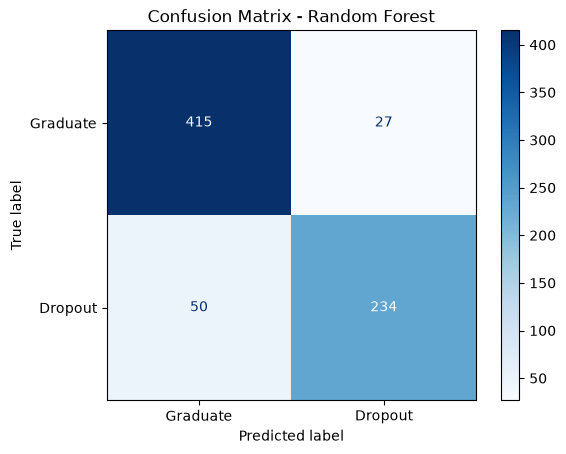

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Graduate", "Dropout"],
    cmap="Blues",
)
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Random Forest

| Model                        | Accuracy | Recall (Dropout) | Precision (Dropout) | F1 (Dropout) | Missed dropouts (FN) | False alarms (FP) |
|------------------------------|----------|------------------|---------------------|--------------|----------------------|-------------------|
| Naive (always "Graduate")    | 61%      | 0%               | -                   | -            | 284                  | 0                 |
| Logistic Regression          | 90%      | **88%**          | 87%                 | **87%**      | **35**               | 38                |
| Random Forest                | 89%      | 82%              | **90%**             | 86%          | 50                   | **27**            |

**Insight:** Random Forest has higher precision (fewer false alarms), but lower recall.
It misses **50** dropout students, compared to **35** for Logistic Regression.
Since missing an at-risk student is the most costly error, **Logistic Regression is the
better model** for our goal.

Possible reasons why Random Forest did not perform better:
- The strongest relationships in the data (grades, tuition fees) are fairly simple and linear.
- After one-hot encoding, most of the 221 features are sparse (mostly zeros).
- The training set is small (2,904 students), and we used default hyperparameters.

**Lesson:** A more complex model is not always better. We keep the simpler model
unless a complex one clearly improves the metric we care about.

## Experiment Tracking with MLflow

In [29]:
import mlflow
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("student-dropout")

2026/10/08 13:37:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/08 13:37:15 INFO mlflow.store.db.utils: Updating database tables
2026/10/08 13:37:19 INFO mlflow.tracking.fluent: Experiment with name 'student-dropout' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:d:/projects/student-dropout-prediction/notebooks/mlruns/1', creation_time=1791459439603, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791459439603, lifecycle_stage='active', name='student-dropout', tags={}, trace_location=None, workspace='default'>

In [30]:
def train_and_log(model, run_name):
    with mlflow.start_run(run_name=run_name):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = {
            "accuracy": accuracy_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
        }

        mlflow.log_param("model_type", run_name)
        mlflow.log_params(model.named_steps["classifier"].get_params())
        mlflow.log_metrics(metrics)

    return metrics

In [32]:
train_and_log(model, "logistic_regression")
train_and_log(rf_model, "random_forest")

{'accuracy': 0.8939393939393939,
 'recall': 0.823943661971831,
 'precision': 0.896551724137931,
 'f1': 0.8587155963302753}

In [34]:
binary_cols_no_tuition = [col for col in binary_cols if col != "tuition_fees_up_to_date"]

preprocessor_no_tuition = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols),
        ("bin", "passthrough", binary_cols_no_tuition),
    ]
)

lr_model_no_tuition = Pipeline(steps=[
    ("preprocessor", preprocessor_no_tuition),
    ("classifier", LogisticRegression(max_iter=1000)),
])

train_and_log(lr_model_no_tuition, "logistic_regression_no_tuition")


{'accuracy': 0.8622589531680441,
 'recall': 0.823943661971831,
 'precision': 0.823943661971831,
 'f1': 0.823943661971831}

## Decision: Removing `tuition_fees_up_to_date`

| Model                            | Recall (Dropout) | Precision (Dropout) | Accuracy | Missed dropouts |
|----------------------------------|------------------|---------------------|----------|-----------------|
| Logistic Regression              | 87.7%            | 86.8%               | 90.2%    | 35              |
| Logistic Regression (no tuition) | 82.4%            | 82.4%               | 86.2%    | 50              |

Removing `tuition_fees_up_to_date` reduces recall by about 5 points (15 more missed students).
The feature is useful, but the model still performs well without it.

**Decision:** We remove this feature from the final model. The dataset does not say *when*
this information was recorded. If it was recorded after the student had already left,
it would cause **data leakage**, and the 87.7% recall would be too optimistic.

**Note:** If a university can confirm tuition status at the end of the first semester,
this feature could be added back, and recall could improve to about 88%.

In [35]:
from sklearn.model_selection import cross_val_predict

y_proba_cv = cross_val_predict(
    lr_model_no_tuition, X_train, y_train,
    cv=5, method="predict_proba",
)[:,1]

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    y_pred_t = (y_proba_cv >= t).astype(int)

    recall_t = recall_score(y_train, y_pred_t)
    precision_t = precision_score(y_train, y_pred_t)

    print(f"threshold={t} : recall={recall_t:.3f}, precision:{precision_t:.3f}")

threshold=0.2 : recall=0.910, precision:0.724
threshold=0.25 : recall=0.894, precision:0.765
threshold=0.3 : recall=0.880, precision:0.797
threshold=0.35 : recall=0.861, precision:0.821
threshold=0.4 : recall=0.840, precision:0.843
threshold=0.45 : recall=0.813, precision:0.863
threshold=0.5 : recall=0.798, precision:0.879


In [41]:
y_proba_test = lr_model_no_tuition.predict_proba(X_test)[:,1]

THRESHOLD = 0.3

y_pred_final = (y_proba_test >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred_final, target_names=["Graduate", "Dropout"]))

              precision    recall  f1-score   support

    Graduate       0.92      0.80      0.86       442
     Dropout       0.74      0.89      0.81       284

    accuracy                           0.84       726
   macro avg       0.83      0.85      0.83       726
weighted avg       0.85      0.84      0.84       726



## Threshold Tuning

The default threshold (0.5) is not ideal for our goal, because missing a dropout student
is more costly than a false alarm. We used **5-fold cross-validation on the training set**
to choose the threshold (the test set was not used for this decision).

We chose **threshold = 0.3**. Below 0.3, recall improves only a little while precision
drops much more (diminishing returns).

### Final Results on Test Set (Logistic Regression, no tuition, threshold = 0.3)

| Metric              | Value |
|---------------------|-------|
| Recall (Dropout)    | 89%   |
| Precision (Dropout) | 74%   |
| F1 (Dropout)        | 81%   |
| Accuracy            | 84%   |

**Insight:** Compared to the default threshold, the model now finds about 19 more
dropout students, at the cost of about 38 more false alarms. Since a false alarm only
means an extra advising session, this is a good trade-off.

Precision on the test set (74%) is lower than in cross-validation (80%). This is normal
variation, and we report the test result as the honest final number.